# Avito Bootcamp DS. Тестовое задание: детекция ботов.

Кратко по задаче:

Нужно по событиям за суточное окно оценить, относится ли кука к трафику сервисов автоматизированного сбора данных. В `train` есть разметка, в `test` её нет. Для каждого `cookie_id` в тесте сформируем `score` от 0 до 1.

Основная метрика — Precision при Recall не ниже 70%. Поэтому будем сравнивать модели по тому, насколько точно они находят ботов при условии, что обнаружено не меньше 70% всех ботов. ROC-AUC используем только как дополнительную оценку.

Сначала посмотрим на данные и соберём признаки из событий внутри разрешённых окон. Затем сравним простой Random Forest с более полными наборами признаков и CatBoost, проверим результат на более поздних датах и сформируем `submission.csv`.


# Импорт модулей


Импортируем необходимые библиотеки, объявляем SEED для воспроизводимости решения, директории для входных и выходных файлов:

In [1]:
from pathlib import Path
import csv, gzip, json, re, sys, platform, shutil, importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

In [2]:
SEED = 42
PATH = Path('/kaggle/input/datasets/callmejaso/avito-bc-ds')
OUT = Path('/kaggle/working/antibot')
PATHS = dict(
    train=None,
    test=None,
    events=None,
    submission=None,
    metric=None
)
OUT.mkdir(parents=True, exist_ok=True)
np.random.seed(SEED)
pd.set_option('display.max_columns', None)

In [3]:
date_columns = [
    'cookie_created_at',
    'window_start_ts',
    'window_end_ts'
]

train = pd.read_csv(PATH / 'train.csv', parse_dates=date_columns)
test = pd.read_csv(PATH / 'test.csv', parse_dates=date_columns)
events = pd.read_csv(PATH / 'events.csv', parse_dates=['event_ts'])

In [4]:
print(f'Тренировочная выборка: {train.shape}\nТестовая выборка: {test.shape}\nСобытия: {events.shape}\n')
print(f'Процент ботов в тренировочной выборке: {train.target.mean():.2%}')


Тренировочная выборка: (11091, 5)
Тестовая выборка: (4909, 4)
События: (328905, 14)

Процент ботов в тренировочной выборке: 8.11%


# Разведочный анализ данных

В задаче есть дисбаланс классов, посмотрим на данные из train и events:

In [5]:
display(train.head())
display(events.head())

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
0,ck_5efbea1befdefe1b,2026-04-26 09:11:24,200,item_view,desktop,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,1027450.0,elektronika,kaliningrad,pro,NaN,NaN,NaN,NaN
1,ck_c4ca1434f3778f1d,2026-04-20 14:04:31,100,search_results_view,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,telefony,habarovsk,NaN,iphone 13 128,4.0,NaN,NaN
2,ck_d274382b19488771,2026-04-13 12:02:56,200,item_view,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,1048743.0,kvartiry_prodazha,kirov,private,NaN,NaN,675.0,276.0
3,ck_fbbed2ff14944ce9,2026-04-08 06:12:14,100,search_results_view,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,bytovaya_tehnika,novosibirsk,NaN,пылесос dyson,2.0,NaN,NaN
4,ck_56cc15c7c634cb9f,2026-04-12 17:16:05,100,search_results_view,WEB,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,NaN,odezhda,sankt-peterburg,NaN,костюм мужской,2.0,NaN,NaN


Внимательно посмотрим на данные events, в особенности на колонки с названиями событий, платформой, категорией и локацией.
Посмотрим, какую долю данных занимает тип события в датасете, какие платформы используются, какие категории, а также города (тоже всё в долях)

In [6]:
columns = ['event_name', 'platform', 'item_category', 'item_location']

for col in columns:
    counts = events[col].value_counts()
    percents = events[col].value_counts(normalize=True) * 100
    df_stats = pd.concat([counts, percents.round(2)], axis=1)
    df_stats.columns = ['Количество', 'Процент (%)']
    df_stats = df_stats.reset_index()
    display(df_stats.style.hide().format({'Процент (%)': '{:.2f}%'}))
    print('\n')

event_name,Количество,Процент (%)
item_view,120817,36.73%
search_results_view,100402,30.53%
photo_swipe,36517,11.10%
favorite_add,19049,5.79%
seller_page_view,17403,5.29%
contact_phone_show,11316,3.44%
captcha_shown,7928,2.41%
login,6267,1.91%
contact_chat_open,6125,1.86%
contact_message_sent,3081,0.94%


platform,Количество,Процент (%)
desktop,46866,14.25%
WEB,46476,14.13%
Web,46365,14.10%
web,45951,13.97%
ANDROID,42462,12.91%
Android,42254,12.85%
android,42159,12.82%
iphone,4103,1.25%
IOS,4100,1.25%
iOS,4091,1.24%


item_category,Количество,Процент (%)
avtomobili,20822,7.03%
mebel,20541,6.94%
bytovaya_tehnika,20161,6.81%
hobbi,20020,6.76%
elektronika,20002,6.76%
uslugi,19869,6.71%
odezhda,19846,6.71%
kvartiry_arenda,19713,6.66%
kvartiry_prodazha,19709,6.66%
noutbuki,19583,6.62%


item_location,Количество,Процент (%)
sankt-peterburg,39221,12.85%
novosibirsk,37989,12.45%
moskva,37964,12.44%
ekaterinburg,37281,12.22%
ryazan,4627,1.52%
izhevsk,4576,1.50%
barnaul,4559,1.49%
astrahan,4511,1.48%
ufa,4481,1.47%
vladivostok,4469,1.46%


В топе по типу событий просмотр товара, просмотр результатов поиска, а также свайп фото (базовые действия, которые делает пользователь, когда что-то ищет или получает из рекомендаций. Боты тоже будут этим заниматься, поэтому будем смотреть дальше).

Категории и города в целом имеют почти равные доли, тут мы выводов по популярности не сделаем. Выделяются лишь 4 города РФ.

Также заметим, что WEB, Web и web - это по факту одно и то же, поэтому можем привести данные к нижнему регистру и пересмотреть их.

In [7]:
events['platform'] = events['platform'].str.strip().str.lower()
counts = events['platform'].value_counts()
percents = events['platform'].value_counts(normalize=True) * 100
df_stats = pd.concat([counts, percents.round(2)], axis=1)
df_stats.columns = ['Количество', 'Процент (%)']
df_stats = df_stats.reset_index()
display(df_stats.style.hide().format({'Процент (%)': '{:.2f}%'}))

platform,Количество,Процент (%)
web,138792,42.20%
android,126875,38.57%
desktop,46866,14.25%
ios,12269,3.73%
iphone,4103,1.25%


Нааименьшее число представляет iphone и ios.

Можно подумать, что web и desktop - одно и то же, но пока отложим этот момент, то же самое с iphone и ios. 

Может, подразумевается, что ios используется в mac, ipad и прочем, хотя у них должны быть свои ОС (по крайней мере после 2019 года у ipad стала выходить своя ОС).

Посмотрим на кол-во пропусков куков на тренировочной выборке, также на пропуски в таблице events:

In [8]:
print(train.isna().sum(), '\n') # Здесь считаем кол-во пропусков
print(events.isna().mean().round(2)) # Здесь же посмотрим на доли пропусков

cookie_id            0
cookie_created_at    0
window_start_ts      0
window_end_ts        0
target               0
dtype: int64 

cookie_id        0.00
event_ts         0.00
eid              0.00
event_name       0.00
platform         0.00
user_agent       0.00
item_id          0.35
item_category    0.10
item_location    0.07
seller_type      0.41
search_query     0.69
search_page      0.69
pointer_x        0.67
pointer_y        0.67
dtype: float64


Пропусков у куков нет, однако во вспомогальных признаков есть доли пропусков.
Например, пропуски в поисковых событиях связаны с типом события, так что удалять, не подумав, нельзя.

Теперь проверим дубликаты, пропуски и окна периодов.

Можно также быстро проверить пересечение train и test (через & двух сетов). 

Проверим полные дубликаты, позже просто выведем их подряд, чтоб посмотреть, как это представлено в данных.

In [9]:
for name, df in [('train', train), ('test', test)]:
    print(f'\n{name}:')
    print('Дубликаты cookie_id:', df['cookie_id'].duplicated().sum())
    print('Пропуски:', df.isna().sum().sum())
    print('Начало периода:', df['window_start_ts'].min())
    print('Конец периода:', df['window_start_ts'].max())

    assert df['cookie_id'].is_unique
    assert df[date_columns].notna().all().all()
    assert (df['window_end_ts'] > df['window_start_ts']).all()

overlap = set(train['cookie_id']) & set(test['cookie_id'])
print('\nПересечение train и test:', len(overlap))
assert len(overlap) == 0

print('Полные дубликаты событий:', events.duplicated().sum())


train:
Дубликаты cookie_id: 0
Пропуски: 0
Начало периода: 2026-04-06 00:00:00
Конец периода: 2026-04-19 00:00:00

test:
Дубликаты cookie_id: 0
Пропуски: 0
Начало периода: 2026-04-20 00:00:00
Конец периода: 2026-04-26 00:00:00

Пересечение train и test: 0
Полные дубликаты событий: 4868


Посмотрим на примеры таких строк. Используем сортировку по id и ts, чтобы визуально посмотреть на эти строки (при такой сортировке дубликаты будут идти один за другим).

In [10]:
display(events[events.duplicated(keep=False)].sort_values(by=['cookie_id', 'event_ts']).head(10))  

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
37283,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
141860,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
314150,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,android,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
321075,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,android,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
10173,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
210391,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN
24981,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN
102678,ck_00389b209b37394b,2026-04-14 16:26:24,200,item_view,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,1026235.0,noutbuki,novosibirsk,private,NaN,NaN,NaN,NaN
80882,ck_00389b209b37394b,2026-04-15 07:51:32,900,captcha_shown,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244462,ck_00389b209b37394b,2026-04-15 07:51:32,900,captcha_shown,android,Mozilla/5.0 (Linux; Android 14; SM-A515F) Appl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Посмотрим также на события, выходящие за обозначенные окна (границы ниже будут именно такие, так как по условию корректными являются ОТ включительно, ДО не включительно, а значит "обратные границы" - ОТ не включительно, ДО включительно).

In [11]:
meta_columns = ['cookie_id', 'window_start_ts', 'window_end_ts']

meta = pd.concat([
    train[meta_columns],
    test[meta_columns]
], ignore_index=True)

ev = events.merge(
    meta,
    on='cookie_id',
    how='left',
    validate='many_to_one'
)

unknown_cookie = ev['window_start_ts'].isna()
before_window = ev['event_ts'] < ev['window_start_ts']
after_window = ev['event_ts'] >= ev['window_end_ts']

print('События неизвестных куков:', unknown_cookie.sum())
print('События раньше окна:', before_window.sum())
print('События на границе конца или позже:', after_window.sum())

inside_window = (
    ~unknown_cookie
    & (ev['event_ts'] >= ev['window_start_ts'])
    & (ev['event_ts'] < ev['window_end_ts'])
)

ev = ev.loc[inside_window].copy()
ev = ev.sort_values(['cookie_id', 'event_ts']).reset_index(drop=True)

print('Событий внутри окон:', len(ev))

print(f'Процент (%) выходящих за границу: {((before_window.sum() + after_window.sum()) / len(events) * 100):.2f}%')

События неизвестных куков: 0
События раньше окна: 0
События на границе конца или позже: 40779
Событий внутри окон: 288126
Процент (%) выходящих за границу: 12.40%


In [12]:
print('Повторные строки внутри окон:', ev.duplicated().sum())
ev = ev.drop_duplicates().copy()
ev = ev.sort_values(['cookie_id', 'event_ts']).reset_index(drop=True)

Повторные строки внутри окон: 4296


In [13]:
columns = [
    'item_id',
    'search_query',
    'search_page',
    'pointer_x',
    'pointer_y'
]

missing_by_event = (ev.groupby('event_name')[columns]
                    .agg(lambda column: column.isna().mean())
                   )

display((missing_by_event * 100).round(1))

missing_by_platform = (ev.groupby('platform')[['pointer_x', 'pointer_y']]
                       .agg(lambda column: column.isna().mean())
                      )

display((missing_by_platform * 100).round(1))

,item_id,search_query,search_page,pointer_x,pointer_y
event_name,,,,,
contact_chat_open,0.0,100.0,100.0,68.6,68.6
contact_message_sent,0.0,100.0,100.0,67.5,67.5
contact_phone_show,0.0,100.0,100.0,67.1,67.1
favorite_add,0.0,100.0,100.0,65.1,65.1
item_view,0.0,100.0,100.0,67.4,67.4
login,100.0,100.0,100.0,64.7,64.7
photo_swipe,0.0,100.0,100.0,65.7,65.7
search_results_view,100.0,0.0,0.0,66.9,66.9
seller_page_view,0.0,100.0,100.0,66.3,66.3


,pointer_x,pointer_y
platform,,
android,100.0,100.0
desktop,40.6,40.6
ios,100.0,100.0
iphone,100.0,100.0
web,40.7,40.7


Действительно, когда идёт действие поиска, то данные условного item_id не должны быть включены в строку, то же самое и с просмотром товара. У событий просмотра объявления поисковые поля не заполняются.

Координаты курсора тоже есть не везде, например, на телефонах его в обычном понимании нет. Стоит также дополнить нашу предыдущую гипотезу, что в ios не входит macos (пк), так как курсора в момент действий не наблюдалось. 

Будем погружаться в данные дальше, чтобы отследить поведения людей и ботов. Попробуем рассмотреть паузы между действиями, кол-во действий, а также указанные идентификаторы объявлений.

Для типичной паузы возьмём медиану, также обратим внимание на то, как сильно паузы различаются (median и std) - выражаем в секундах.

Для общего времени активности используем минуты, в секундах смотреть будет не очень удобно.

In [14]:
ev['gap_seconds'] = (
    ev.groupby('cookie_id')['event_ts']
    .diff()
    .dt.total_seconds()
)

features = ev.groupby('cookie_id').agg(
    n_events=('event_name', 'size'),
    n_items=('item_id', 'nunique'),
    n_categories=('item_category', 'nunique'),
    n_queries=('search_query', 'nunique'),
    first_event=('event_ts', 'min'),
    last_event=('event_ts', 'max'),
    median_gap=('gap_seconds', 'median'),
    std_gap=('gap_seconds', 'std')
)

features['activity_minutes'] = (
    features['last_event'] - features['first_event']
).dt.total_seconds() / 60

features = features.drop(columns=['first_event', 'last_event'])

train_features = train.merge(
    features,
    on='cookie_id',
    how='left',
    validate='one_to_one'
)

count_columns = ['n_events', 'n_items', 'n_categories', 'n_queries']
train_features[count_columns] = (
    train_features[count_columns].fillna(0)
)

print(
    'Кол-во куков без событий внутри окна:',
    train_features['n_events'].eq(0).sum()
)

display(train_features.head())

Кол-во куков без событий внутри окна: 0


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target,n_events,n_items,n_categories,n_queries,median_gap,std_gap,activity_minutes
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0,7,4,3,3,21.0,29.949402,2.783333
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0,41,19,1,5,57.5,2416.286861,657.933333
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0,36,19,7,10,22.0,2306.449400,608.183333
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0,21,10,1,3,54.5,2502.081501,287.016667
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0,28,16,4,6,52.0,1748.439172,318.300000


Пока видим, что куки с большим кол-вом событий имеют большое кол-во минут, это и логично, что чем больше действий, тем больше времени у нас они могут занять, однако на таком малом обозреваемом кол-ве данных мы не можем сделать окончательный вывод.

Однако можем проверить максимальные, минимальные, средние значения пауз и минут активности:

In [15]:
train_features[['n_events', 'n_items', 'n_categories', 'n_queries', 'median_gap', 'std_gap', 'activity_minutes']].describe()

,n_events,n_items,n_categories,n_queries,median_gap,std_gap,activity_minutes
count,11091.000000,11091.000000,11091.000000,11091.000000,10837.000000,10441.000000,11091.000000
mean,17.625282,9.311334,2.241187,3.868362,215.988835,1626.567664,194.317502
std,17.437651,9.287745,1.234674,3.206534,752.650804,1124.819609,204.407638
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,3.000000,1.000000,2.000000,35.000000,689.031407,29.558333
50%,12.000000,6.000000,2.000000,3.000000,58.000000,1713.411521,140.166667
75%,23.000000,12.000000,3.000000,5.000000,100.000000,2369.300785,279.041667
max,165.000000,80.000000,8.000000,29.000000,9005.000000,6356.182856,1391.466667


По среднему времени активности можем выделить примерно 194 минут, паузы примерно по 210 секунд. Да, конечно есть большие значения в виде 9000 секунд по паузам, 6300 по std. Для этого мы и посмотрели через describe. Так у нас будет больше представления о данных.

На тренировочных данных посмотрим по получившимся признакам значения таргета. Так мы сможем более точно посмотреть, чем выделяются боты.
Группируем, считаем медиану и среднее:

In [16]:
eda = train_features[
    train_features['window_start_ts'] < '2026-04-17'
].copy()

feature_columns = [
    'n_events',
    'n_items',
    'n_categories',
    'n_queries',
    'activity_minutes',
    'median_gap',
    'std_gap'
]

display(
    eda.groupby('target')[feature_columns]
    .agg(['median', 'mean'])
    .round(2)
)

n_events        n_items        n_categories       n_queries        \
         median   mean  median   mean       median  mean    median  mean   
target                                                                     
0          11.0  16.46     6.0   8.83          2.0  2.27       3.0  3.76   
1          20.0  29.43    11.0  13.98          2.0  1.78       4.0  4.80   

       activity_minutes         median_gap          std_gap           
                 median    mean     median    mean   median     mean  
target                                                                
0                137.78  193.43       61.0  231.96  1751.12  1659.11  
1                152.15  200.58       25.0   96.17  1372.28  1322.24

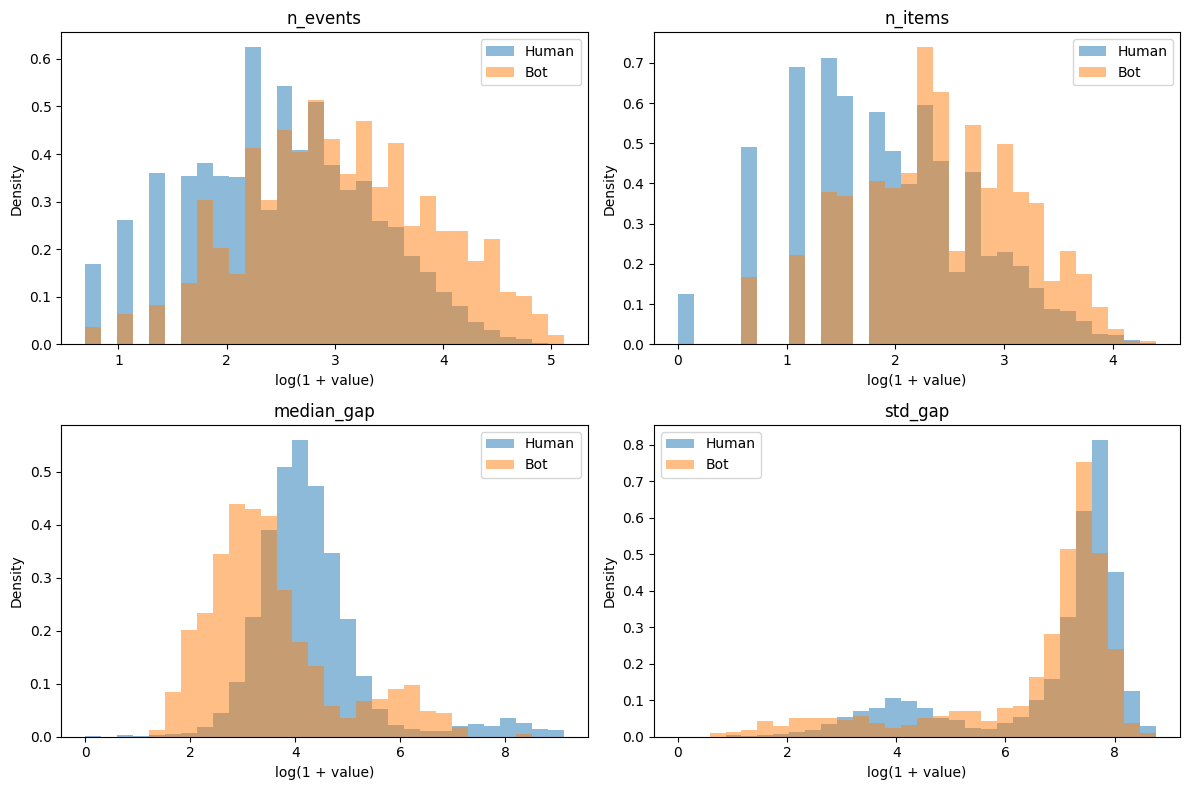

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_columns = [
    'n_events',
    'n_items',
    'median_gap',
    'std_gap'
]

for ax, column in zip(axes.flat, plot_columns):
    values = np.log1p(eda[column].dropna())
    bins = np.histogram_bin_edges(values, bins=30)
    
    for target, label in [(0, 'Human'), (1, 'Bot')]:
        group = eda.loc[eda['target'] == target, column].dropna()
        if len(group) > 0:
            ax.hist(
                np.log1p(group),
                bins=bins,
                density=True,
                alpha=0.5,
                label=label
            )
    ax.set_title(column)
    ax.set_xlabel('log(1 + value)')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

Какой вывод мы можем сделать на данный момент: боты в среднем совершают больше действий, взаимодействуют с большим кол-вом объявлений. Также, если посмотреть на паузы, то у ботов медианные паузы короче, однако по факту распределения классов пересекаются достаточно существенно, так что отдельного признака сейчас будет недостаточно. Можно проверять сочетания признаков.

Уделим пока внимание капче. Это одно из событий (captcha_shown), которое можно потенциально использовать при проверке на бота:

In [18]:
print(
    'Капчи до фильтрации:',
    events['event_name'].eq('captcha_shown').sum()
)
print(
    'Капчи внутри окон:',
    ev['event_name'].eq('captcha_shown').sum()
)

Капчи до фильтрации: 7928
Капчи внутри окон: 0


Капчи внутри окон проверки не существуют, по правилам мы не можем использовать признак за пределами доступной истории.

Посмотрим на доли типов действий на каждый кук. Так мы можем проверить, каакие именно действия совершают юзеры. Изобразим в таблице и на графике:

target,0,1
contact_chat_open,1.69,1.83
contact_message_sent,0.80,1.05
contact_phone_show,3.13,3.18
favorite_add,6.80,3.24
item_view,36.32,42.32
login,2.32,1.03
photo_swipe,12.73,7.88
search_results_view,30.91,33.30
seller_page_view,5.28,6.17


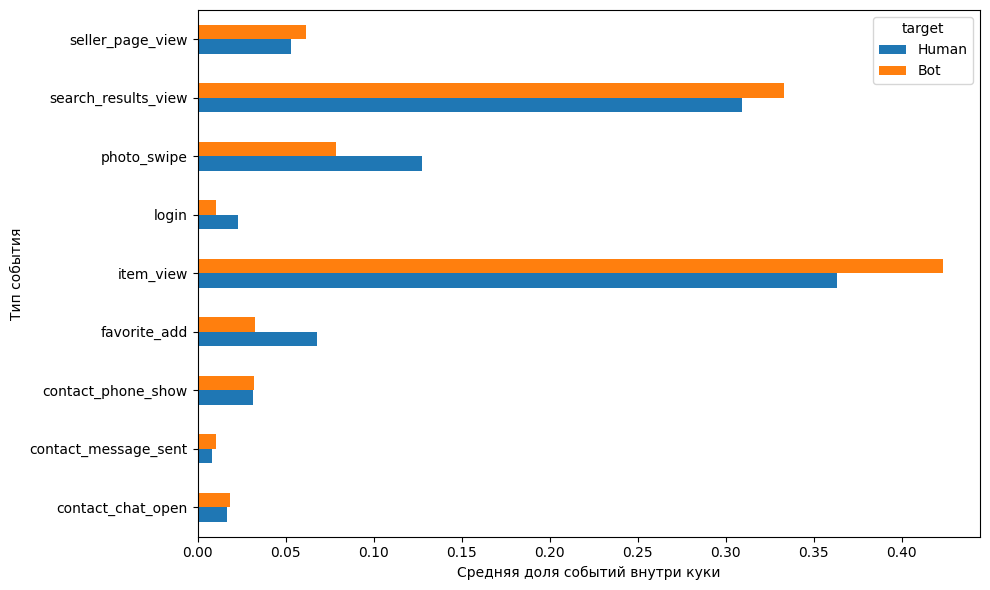

In [19]:
event_counts = pd.crosstab(
    ev['cookie_id'],
    ev['event_name']
)

event_shares = event_counts.div(
    event_counts.sum(axis=1),
    axis=0
)

eda_event_shares = (
    train.loc[
        train['window_start_ts'] < '2026-04-17',
        ['cookie_id', 'target']
    ]
    .merge(event_shares, on='cookie_id', how='left')
)

mean_shares = (
    eda_event_shares
    .groupby('target')[event_shares.columns]
    .mean()
    .T
)

display((mean_shares * 100).round(2))

mean_shares.rename(
    columns={0: 'Human', 1: 'Bot'}
).plot.barh(figsize=(10, 6))

plt.xlabel('Средняя доля событий внутри куки')
plt.ylabel('Тип события')
plt.tight_layout()
plt.show()

По таблице и графику видно, что люди чаще подробно осматривают объявления (photo_swipe), входят в аккаунт (login), а также добавляют в избранное (favorite_add).

Понятно, что доля не означает абсолют. Помним, что у ботов же событий больше. Разброс мы тут тоже не учитываем, чем-то конкретные люди пользоваться могут, чем-то - определённые боты. Однако всё же наша интерпретация допустима.

# Получение признаков
Перейдём к User-Agent. Проанализируем способы захода на сайт:

In [20]:
dev_ids = train.loc[
    train['window_start_ts'] < '2026-04-17',
    'cookie_id'
]

dev_events = ev[ev['cookie_id'].isin(dev_ids)]
print('Разных User-Agent:', dev_events['user_agent'].nunique())

ua_counts = (
    dev_events[['cookie_id', 'user_agent']]
    .drop_duplicates()
    ['user_agent']
    .value_counts()
    .rename_axis('user_agent')
    .reset_index(name='n_cookies')
)
with pd.option_context('display.max_colwidth', 100):
    display(ua_counts.head(20))

Разных User-Agent: 148


,user_agent,n_cookies
0,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0....",130
1,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/117.0.0....",130
2,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/125.0.0....",124
3,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0....",120
4,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0....",120
5,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:119.0) Gecko/20100101 Firefox/119.0,117
6,"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/116.0.0....",117
7,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:113.0) Gecko/20100101 Firefox/113.0,116
8,"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/11...",114
9,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:123.0) Gecko/20100101 Firefox/123.0,114


Посмотрим на первые 20 UA. При дальнейшем выводе будет много вариаций какого-то браузера, только с разными версиями. Лучше с помощью группировки посмотреть на кол-во UA на кук:

In [21]:
ua_per_cookie = (
    dev_events.groupby('cookie_id')['user_agent']
    .nunique()
    .rename('n_user_agents')
)

ua_distribution = (
    ua_per_cookie.value_counts()
    .sort_index()
    .rename_axis('n_user_agents')
    .reset_index(name='n_cookies')
)

ua_distribution['%'] = (
    ua_distribution['n_cookies']
    / ua_distribution['n_cookies'].sum()
    * 100
)

display(ua_distribution.round(2))

,n_user_agents,n_cookies,%
0,1,8484,92.82
1,2,89,0.97
2,3,567,6.20


In [22]:
ua_analysis = (
    train.loc[
        train['window_start_ts'] < '2026-04-17',
        ['cookie_id', 'target']
    ]
    .merge(ua_per_cookie, on='cookie_id', how='left')
)

ua_summary = (
    ua_analysis.groupby('n_user_agents')
    .agg(
        n_cookies=('target', 'size'),
        n_bots=('target', 'sum'),
        bot_rate=('target', 'mean')
    )
)

ua_summary['bot_rate_percent'] = ua_summary.pop('bot_rate') * 100

display(ua_summary
        .reset_index()
        .round(2)
        .style.hide()
        .format({'bot_rate_percent': '{:.2f}%'}))

print(
    'Доля ботов в исследуемой части train:',
    f"{ua_analysis['target'].mean():.2%}"
)

n_user_agents,n_cookies,n_bots,bot_rate_percent
1,8484,697,8.22%
2,89,1,1.12%
3,567,41,7.23%


Доля ботов в исследуемой части train: 8.09%


Итого, для куков с одним или тремя User-Agent доля ботов близка к общей, а среди двух метрика ниже, хотя рассматриваемая группа заметно меньше (1 бот на 89 куков), полезность есть смысл смотреть на валидации. 

Напишем простой парсер на UA (он не универсальный, но картину общую сформировать поможет). Также заметим, почему проверяем яндекс раньше: дело в том, что яндекс также содержит хром, так что целесообразно хром кинуть в конец проверок:

In [23]:
def get_client_family(user_agent):
    ua = user_agent.lower()
    
    if 'avito/' in ua:
        return 'avito_app'
    if 'headlesschrome' in ua:
        return 'headless_chrome'
    if 'yabrowser' in ua:
        return 'yandex'
    if 'edg/' in ua or 'edga/' in ua or 'edgios/' in ua:
        return 'edge'
    if 'opr/' in ua or 'opera' in ua:
        return 'opera'
    if 'firefox/' in ua or 'fxios/' in ua:
        return 'firefox'
    if 'chrome/' in ua or 'crios/' in ua:
        return 'chrome'
    if 'safari/' in ua:
        return 'safari'
    return 'other'

Применим парсер, а также обратим внимание на режим браузера без графического интерфейса. Пока это только кандидат в признак, а не точный показатель бота. Создадим небольшую таблицу по UA-признакам:

In [24]:
ev['client_family'] = ev['user_agent'].apply(get_client_family)

ev['is_headless'] = (
    ev['user_agent']
    .str.contains('headless', case=False, na=False)
)

In [25]:
ua_features = ev.groupby('cookie_id').agg(
    n_user_agents=('user_agent', 'nunique'),
    client_family=('client_family', lambda x: x.mode().iloc[0]),
    has_headless=('is_headless', 'max')
)

display(ua_features.head())

,n_user_agents,client_family,has_headless
cookie_id,,,
ck_00013fdfa0bd37dd,1,chrome,False
ck_000c95f1408dcb00,1,chrome,False
ck_000e8c52636e3bec,1,firefox,False
ck_0010e31baa4a1fb7,1,yandex,False
ck_0010ec3874fb5378,1,yandex,False


Улучшим восприятие таблицей ниже. По клиентам, полученным от парсера, посмотрим на куки, кол-во ботов и процент этих ботов от людей.

In [26]:
ua_eda = (
    train.loc[train['window_start_ts'] < '2026-04-17', ['cookie_id', 'target']]
    .merge(ua_features, on='cookie_id', how='left')
)

client_summary = (
    ua_eda.groupby('client_family')
    .agg(
        n_cookies=('target', 'size'),
        n_bots=('target', 'sum'),
        bot_rate=('target', 'mean')
    )
    .sort_values('n_cookies', ascending=False)
)

client_summary['bot_rate_percent'] = (
    client_summary.pop('bot_rate') * 100
)
display(client_summary.round(2).style.format({'bot_rate_percent': '{}%'}))

,n_cookies,n_bots,bot_rate_percent
client_family,,,
chrome,4678,293,6.26%
avito_app,1775,154,8.68%
firefox,1163,98,8.43%
yandex,974,85,8.73%
headless_chrome,231,64,27.71%
other,166,37,22.29%
safari,153,8,5.23%


headless_chrome и other имеют высокие показатели, chrome и safari - ниже общего процента (в районе 8%). Посмотрим на процент ботов просто при наличии режима без графики:

In [27]:
headless_summary = (
    ua_eda.groupby('has_headless')
    .agg(
        n_cookies=('target', 'size'),
        n_bots=('target', 'sum'),
        bot_rate=('target', 'mean')
    )
)

headless_summary['bot_rate_percent'] = (
    headless_summary.pop('bot_rate') * 100
)

display(headless_summary.round(2))

,n_cookies,n_bots,bot_rate_percent
has_headless,,,
False,8909,675,7.58
True,231,64,27.71


Ботов здесь на has_headless = True мало. Тип клиента можно использовать с поведением юзера.

# Обучение моделей

Из EDA у нас появились признаки количества и типов действий, пауз между ними и User-Agent. Теперь проверим, помогают ли они определять ботов.

Для первого ориентира обучим Random Forest только на числе событий и уникальных объявлений. Потом на том же временном разбиении добавим остальные поведенческие признаки, доли действий и характеристики User-Agent. Метрику посчитаем функцией `precision_at_recall` из выданного `metric.py`.

In [28]:
sys.path.insert(0, str(PATH))
from metric import precision_at_recall

event_counts = pd.crosstab(ev['cookie_id'], ev['event_name'])
event_shares = event_counts.div(event_counts.sum(axis=1), axis=0)
event_shares = event_shares.add_prefix('share_')

# Характеристики UA внутри окна
ev['client_family'] = ev['user_agent'].apply(get_client_family)

ua_features = ev.groupby('cookie_id').agg(
    n_user_agents=('user_agent', 'nunique'),
    client_family=('client_family', lambda x: x.mode().iloc[0])
)

# Здесь одна строка на кук; target и дата окна берутся только из train
model_data = (
    train[['cookie_id', 'window_start_ts', 'target']]
    .merge(features, on='cookie_id', how='left', validate='one_to_one')
    .merge(event_shares, on='cookie_id', how='left', validate='one_to_one')
    .merge(ua_features, on='cookie_id', how='left', validate='one_to_one')
)

share_columns = event_shares.columns.tolist()
model_data[share_columns] = model_data[share_columns].fillna(0)

# Если нет событий, значит нет счётчиков и долей; просто паузы не определяем
count_columns = ['n_events', 'n_items', 'n_categories', 'n_queries',
                 'n_user_agents', 'activity_minutes']
model_data[count_columns] = model_data[count_columns].fillna(0)
model_data[['median_gap', 'std_gap']] = (
    model_data[['median_gap', 'std_gap']].fillna(-1)
)
model_data['client_family'] = model_data['client_family'].fillna('unknown')

Случайно перемешивать куки для валидации не будем: тестовые даты идут позже обучающих, так сначала обучаем модель на 6-13 апреля и проверяем на 14-16 апреля. Позже обучим её на 6-16 апреля и посмотрим результат на 17-19 апреля.

Признаки каждой куки рассчитаны только из её собственных событий внутри окна. При этом метки проверочного периода не передаются в обучение.

In [29]:
fit_mask = model_data['window_start_ts'] < '2026-04-14'
valid_mask = (
    (model_data['window_start_ts'] >= '2026-04-14')
    & (model_data['window_start_ts'] < '2026-04-17')
)

fit_data = model_data.loc[fit_mask]
valid_data = model_data.loc[valid_mask]

print('Обучение:', len(fit_data), 'кук, ботов:', fit_data['target'].sum())
print('Валидация:', len(valid_data), 'кук, ботов:', valid_data['target'].sum())

Обучение: 6773 кук, ботов: 544
Валидация: 2367 кук, ботов: 195


In [30]:
baseline_columns = ['n_events', 'n_items']
behavior_columns = baseline_columns + [
    'n_categories', 'n_queries',
    'activity_minutes', 'median_gap', 'std_gap'
] + share_columns

# Кодируем категорию по обучающей части
fit_ua = pd.get_dummies(fit_data['client_family'], prefix='client', dtype=int)
valid_ua = pd.get_dummies(valid_data['client_family'], prefix='client', dtype=int)
valid_ua = valid_ua.reindex(columns=fit_ua.columns, fill_value=0)
X_fit_ua = pd.concat(
    [fit_data[behavior_columns + ['n_user_agents']], fit_ua],
    axis=1
)
X_valid_ua = pd.concat(
    [valid_data[behavior_columns + ['n_user_agents']], valid_ua],
    axis=1
)

experiments = {
    'Baseline: 2 признака': (
        fit_data[baseline_columns],
        valid_data[baseline_columns]
    ),
    'Поведение и доли действий': (
        fit_data[behavior_columns],
        valid_data[behavior_columns]
    ),
    'Поведение и User-Agent': (X_fit_ua, X_valid_ua)
}
results = []

for name, (X_fit, X_valid) in experiments.items():
    model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=SEED,
        n_jobs=-1
    )
    model.fit(X_fit, fit_data['target'])
    scores = model.predict_proba(X_valid)[:, 1]

    results.append({
        'experiment': name,
        'P@R≥0.70': precision_at_recall(valid_data['target'], scores)
    })

display(pd.DataFrame(results).round(4))
print('Уровень константного скора:', round(valid_data['target'].mean(), 4))

,experiment,P@R≥0.70
0,Baseline: 2 признака,0.1032
1,Поведение и доли действий,0.3460
2,Поведение и User-Agent,0.3596


Уровень константного скора: 0.0824


Модель на двух счётчиках получила P@R≥0.70 = 0.1032 при доле ботов в проверочной части 0.0824. После добавления поведенческих признаков и долей действий метрика выросла до 0.3460, а с User-Agent - до 0.3596. Основное улучшение здесь дали характеристики поведения. User-Agent добавил небольшой прирост. Проверим модель с полным набором этих признаков на более поздних датах:

На следующем временном периоде обучаем ту же версию Random Forest уже на данных 6-16 апреля. Проверка на 17-19 апреля покажет, сохраняется ли результат при переходе к более поздним кукам.

In [31]:
train_mask = model_data['window_start_ts'] < '2026-04-17'
holdout_mask = model_data['window_start_ts'] >= '2026-04-17'

train_period = model_data.loc[train_mask]
holdout = model_data.loc[holdout_mask]

# Категории клиента кодируем по обучающему периоду
train_ua = pd.get_dummies(
    train_period['client_family'], prefix='client', dtype=int
)
holdout_ua = pd.get_dummies(
    holdout['client_family'], prefix='client', dtype=int
).reindex(columns=train_ua.columns, fill_value=0)

numeric_columns = behavior_columns + ['n_user_agents']

X_train = pd.concat(
    [train_period[numeric_columns], train_ua], axis=1
)
X_holdout = pd.concat(
    [holdout[numeric_columns], holdout_ua], axis=1
)

holdout_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1
)
holdout_model.fit(X_train, train_period['target'])

holdout_scores = holdout_model.predict_proba(X_holdout)[:, 1]

print('Обучающих кук:', len(train_period))
print('Кук в отложенном периоде:', len(holdout))
print(
    'P@R≥0.70 на 17-19 апреля:',
    round(precision_at_recall(holdout['target'], holdout_scores), 4)
)
print(
    'Доля ботов в отложенном периоде:',
    round(holdout['target'].mean(), 4)
)

Обучающих кук: 9140
Кук в отложенном периоде: 1951
P@R≥0.70 на 17-19 апреля: 0.3478
Доля ботов в отложенном периоде: 0.082


Теперь сравним алгоритмы на одинаковых признаках и датах. CatBoost умеет работать с `client_family` как с категориальным признаком, поэтому отдельные One-Hot столбцы для него не создаём. Параметры пока фиксируем без подбора:

In [32]:
cat_columns = behavior_columns + ['n_user_agents', 'client_family']

cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=SEED,
    verbose=False
)

cat_model.fit(
    fit_data[cat_columns],
    fit_data['target'],
    cat_features=['client_family']
)

cat_scores = cat_model.predict_proba(
    valid_data[cat_columns]
)[:, 1]

print(
    'CatBoost, P@R≥0.70 на 14-16 апреля:',
    round(precision_at_recall(valid_data['target'], cat_scores), 4)
)
print('Random Forest на этих датах: 0.3596')

CatBoost, P@R≥0.70 на 14-16 апреля: 0.3603
Random Forest на этих датах: 0.3596


# Дополнительные признаки

RF и CatBoost на первом наборе показали почти одинаковый результат: 0.3596 и 0.3603. Значит, попробуем подробнее описать саму куку: добавим максимальную страницу поиска, долю событий с координатами, разнообразие локаций и платформ, а также возраст куки к началу окна. Это доступно к моменту окончания окна.

In [33]:
extra = ev.groupby('cookie_id').agg(
    max_search_page=('search_page', 'max'),
    pointer_share=('pointer_x', lambda x: x.notna().mean()),
    n_locations=('item_location', 'nunique'),
    n_platforms=('platform', 'nunique')
)

model_data_v2 = (
    model_data
    .merge(extra, on='cookie_id', how='left', validate='one_to_one')
    .merge(
        train[['cookie_id', 'cookie_created_at']],
        on='cookie_id',
        how='left',
        validate='one_to_one'
    )
)

model_data_v2['cookie_age_days'] = (
    model_data_v2['window_start_ts']
    - model_data_v2['cookie_created_at']
).dt.total_seconds() / 86400

new_columns = [
    'max_search_page',
    'pointer_share',
    'n_locations',
    'n_platforms',
    'cookie_age_days'
]

model_data_v2[new_columns] = model_data_v2[new_columns].fillna(0)

In [34]:
fit_v2 = model_data_v2.loc[
    model_data_v2['window_start_ts'] < '2026-04-14'
]

valid_v2 = model_data_v2.loc[
    (model_data_v2['window_start_ts'] >= '2026-04-14')
    & (model_data_v2['window_start_ts'] < '2026-04-17')
]

cat_columns_v2 = (
    behavior_columns
    + ['n_user_agents', 'client_family']
    + new_columns
)

cat_model_v2 = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=SEED,
    verbose=False
)

cat_model_v2.fit(
    fit_v2[cat_columns_v2],
    fit_v2['target'],
    cat_features=['client_family']
)

scores_v2 = cat_model_v2.predict_proba(
    valid_v2[cat_columns_v2]
)[:, 1]

print('CatBoost до новых признаков: 0.3603')
print(
    'CatBoost с новыми признаками:',
    round(precision_at_recall(valid_v2['target'], scores_v2), 4)
)

CatBoost до новых признаков: 0.3603
CatBoost с новыми признаками: 0.4363


Новые признаки подняли метрику CatBoost на 14-16 апреля с 0.3603 до 0.4363. Теперь проверим эту же версию на 17-19 апреля, обучив её на более длинном предыдущем периоде.

In [35]:
train_v2 = model_data_v2.loc[
    model_data_v2['window_start_ts'] < '2026-04-17'
]

holdout_v2 = model_data_v2.loc[
    model_data_v2['window_start_ts'] >= '2026-04-17'
]

cat_holdout_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=SEED,
    verbose=False
)

cat_holdout_model.fit(
    train_v2[cat_columns_v2],
    train_v2['target'],
    cat_features=['client_family']
)

holdout_scores_v2 = cat_holdout_model.predict_proba(
    holdout_v2[cat_columns_v2]
)[:, 1]

print(
    'CatBoost v2, P@R≥0.70 на 17-19 апреля:',
    round(
        precision_at_recall(holdout_v2['target'], holdout_scores_v2),
        4
    )
)
print(
    'CatBoost v2, ROC-AUC на 17-19 апреля:',
    round(roc_auc_score(holdout_v2['target'], holdout_scores_v2), 4)
)

CatBoost v2, P@R≥0.70 на 17-19 апреля: 0.5068
CatBoost v2, ROC-AUC на 17-19 апреля: 0.8888


# Проверка темпа и повторных просмотров

Отдельно проверим, помогут ли доля коротких пауз, минимальная пауза и повторные просмотры объявлений, это мы посмотрим по метрике:

In [36]:
ev['short_gap'] = ev['gap_seconds'].lt(10) & ev['gap_seconds'].notna()

pace = ev.groupby('cookie_id').agg(
    short_gap_share=('short_gap', 'mean'),
    min_gap=('gap_seconds', 'min')
)

item_views = ev.loc[
    ev['event_name'].eq('item_view')
].groupby('cookie_id').agg(
    n_item_views=('event_name', 'size'),
    n_viewed_items=('item_id', 'nunique')
)

item_views['repeat_view_share'] = (
    1 - item_views['n_viewed_items'] / item_views['n_item_views']
)

model_data_v3 = (
    model_data_v2
    .merge(pace, on='cookie_id', how='left', validate='one_to_one')
    .merge(
        item_views[['repeat_view_share']],
        on='cookie_id',
        how='left',
        validate='one_to_one'
    )
)

pace_columns = ['short_gap_share', 'min_gap', 'repeat_view_share']
model_data_v3[pace_columns] = model_data_v3[pace_columns].fillna(0)

In [37]:
fit_v3 = model_data_v3.loc[
    model_data_v3['window_start_ts'] < '2026-04-14'
]

valid_v3 = model_data_v3.loc[
    (model_data_v3['window_start_ts'] >= '2026-04-14')
    & (model_data_v3['window_start_ts'] < '2026-04-17')
]

cat_columns_v3 = (
    behavior_columns
    + ['n_user_agents', 'client_family']
    + new_columns
    + pace_columns
)

cat_model_v3 = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=SEED,
    verbose=False
)

cat_model_v3.fit(
    fit_v3[cat_columns_v3],
    fit_v3['target'],
    cat_features=['client_family']
)

scores_v3 = cat_model_v3.predict_proba(
    valid_v3[cat_columns_v3]
)[:, 1]
vd = valid_v3['target']
print('CatBoost v2, P@R≥0.70: 0.4363')
print(
    'CatBoost v3, P@R≥0.70:',
    round(precision_at_recall(valid_v3['target'], scores_v3), 4)
)
print('CatBoost v3, ROC-AUC:', round(roc_auc_score(vd, scores_v3), 4))

CatBoost v2, P@R≥0.70: 0.4363
CatBoost v3, P@R≥0.70: 0.4241
CatBoost v3, ROC-AUC: 0.905


На 14-16 апреля добавление этих трёх признаков снизило P@R≥0.70 с 0.4363 до 0.4241. Посмотрим также результат на следующем периоде. Так как мы уже сравниваем несколько вариантов на одних и тех же датах, этот период далее считаем частью внутренней валидации, а не финальным тестом:

In [38]:
train_v3 = model_data_v3.loc[
    model_data_v3['window_start_ts'] < '2026-04-17'
]

holdout_v3 = model_data_v3.loc[
    model_data_v3['window_start_ts'] >= '2026-04-17'
]

cat_holdout_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=SEED,
    verbose=False
)

cat_holdout_model.fit(
    train_v3[cat_columns_v3],
    train_v3['target'],
    cat_features=['client_family']
)

holdout_scores_v3 = cat_holdout_model.predict_proba(
    holdout_v3[cat_columns_v3]
)[:, 1]

print(
    'CatBoost v3, P@R≥0.70 на 17-19 апреля:',
    round(
        precision_at_recall(holdout_v3['target'], holdout_scores_v3),
        4
    )
)
print(
    'CatBoost v3, ROC-AUC на 17-19 апреля:',
    round(roc_auc_score(holdout_v3['target'], holdout_scores_v3), 4)
)

CatBoost v3, P@R≥0.70 на 17-19 апреля: 0.6022
CatBoost v3, ROC-AUC на 17-19 апреля: 0.8969


# Характеристики координат

В первоначальном наборе мы учитывали только долю событий с координатами. Теперь попробуем описать сами записанные точки: разброс по осям, охваченную прямоугольную область, долю уникальных точек, расстояния и скорость между последовательными записями, повторение координат и крупные скачки.

Расстояние и скорость считаем только между точками с разными временными метками. Эти значения описывают записи в журнале, а не непрерывную траекторию мыши. Добавим признаки к версии с возрастом куки и стр. поиска:

In [39]:
pointer_events = (
    ev.dropna(subset=['pointer_x', 'pointer_y'])
      .sort_values(['cookie_id', 'event_ts'], kind='stable')
      .copy()
)

pg = pointer_events.groupby('cookie_id')

# Разброс координат и число разных записанных точек
pointer_stats = pg.agg(
    pointer_x_std=('pointer_x', 'std'),
    pointer_y_std=('pointer_y', 'std'),
    pointer_x_min=('pointer_x', 'min'),
    pointer_x_max=('pointer_x', 'max'),
    pointer_y_min=('pointer_y', 'min'),
    pointer_y_max=('pointer_y', 'max')
)

pointer_stats['pointer_area'] = (
    (pointer_stats['pointer_x_max'] - pointer_stats['pointer_x_min'])
    * (pointer_stats['pointer_y_max'] - pointer_stats['pointer_y_min'])
)

unique_points = (
    pointer_events
    .drop_duplicates(['cookie_id', 'pointer_x', 'pointer_y'])
    .groupby('cookie_id')
    .size()
)

pointer_stats['unique_point_share'] = unique_points / pg.size()

# Переходы между точками с разными временными метками
dx = pg['pointer_x'].diff()
dy = pg['pointer_y'].diff()
dt = pg['event_ts'].diff().dt.total_seconds()

pointer_events['step_distance'] = np.hypot(dx, dy).where(dt > 0)


pointer_events['pointer_speed'] = (
    pointer_events['step_distance'] / dt
).where(dt > 0)

pointer_events['large_jump'] = (
    pointer_events['step_distance']
    .ge(500)
    .where(pointer_events['step_distance'].notna())
    .astype(float)
)

pointer_events['same_point'] = (
    pointer_events['step_distance']
    .eq(0)
    .where(pointer_events['step_distance'].notna())
    .astype(float)
)

step_stats = pointer_events.groupby('cookie_id').agg(
    median_pointer_step=('step_distance', 'median'),
    same_point_share=('same_point', 'mean'),
    median_pointer_speed=('pointer_speed', 'median'),
    large_jump_share=('large_jump', 'mean')
)

pointer_stats = pointer_stats.join(step_stats).drop(
    columns=[
        'pointer_x_min', 'pointer_x_max',
        'pointer_y_min', 'pointer_y_max'
    ]
)

pointer_columns = pointer_stats.columns.tolist()
display(pointer_stats.head())

,pointer_x_std,pointer_y_std,pointer_area,unique_point_share,median_pointer_step,same_point_share,median_pointer_speed,large_jump_share
cookie_id,,,,,,,,
ck_000c95f1408dcb00,494.980875,338.074640,1793546.0,1.0,556.059349,0.0,10.600587,0.600000
ck_000e8c52636e3bec,561.544146,277.719426,1929840.0,1.0,794.766253,0.0,28.927101,0.700000
ck_0010e31baa4a1fb7,501.890941,361.434157,1480450.0,1.0,708.593678,0.0,1.696894,0.800000
ck_001e42551cd06e40,440.479609,334.232668,1208775.0,1.0,691.899565,0.0,12.377865,0.666667
ck_0029775566c17ac5,793.114304,241.160735,1070895.0,1.0,389.638355,0.0,8.888566,0.250000


In [40]:
model_data_pointer = model_data_v2.merge(
    pointer_stats,
    on='cookie_id',
    how='left',
    validate='one_to_one'
)

# Минус один значит, что характеристика не определена
model_data_pointer[pointer_columns] = (
    model_data_pointer[pointer_columns].fillna(-1)
)

fit_pointer = model_data_pointer.loc[
    model_data_pointer['window_start_ts'] < '2026-04-14'
]

valid_pointer = model_data_pointer.loc[
    (model_data_pointer['window_start_ts'] >= '2026-04-14')
    & (model_data_pointer['window_start_ts'] < '2026-04-17')
]

cat_columns_pointer = cat_columns_v2 + pointer_columns

pointer_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=SEED,
    verbose=False
)

pointer_model.fit(
    fit_pointer[cat_columns_pointer],
    fit_pointer['target'],
    cat_features=['client_family']
)

pointer_scores = pointer_model.predict_proba(
    valid_pointer[cat_columns_pointer]
)[:, 1]

print('v2 на 14-16 апреля: 0.4363')
print(
    'v2 + координаты на 14-16 апреля:',
    round(
        precision_at_recall(valid_pointer['target'], pointer_scores),
        4
    )
)
print(
    'ROC-AUC:',
    round(roc_auc_score(valid_pointer['target'], pointer_scores), 4)
)

v2 на 14-16 апреля: 0.4363
v2 + координаты на 14-16 апреля: 0.5708
ROC-AUC: 0.9217


In [41]:
train_pointer = model_data_pointer.loc[
    model_data_pointer['window_start_ts'] < '2026-04-17'
]
holdout_pointer = model_data_pointer.loc[
    model_data_pointer['window_start_ts'] >= '2026-04-17'
]

pointer_holdout_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    random_seed=SEED,
    verbose=False
)

pointer_holdout_model.fit(
    train_pointer[cat_columns_pointer],
    train_pointer['target'],
    cat_features=['client_family']
)

pointer_holdout_scores = pointer_holdout_model.predict_proba(
    holdout_pointer[cat_columns_pointer]
)[:, 1]

print('v2 на 17-19 апреля: 0.5068')
print(
    'v2 + координаты на 17-19 апреля:',
    round(
        precision_at_recall(
            holdout_pointer['target'],
            pointer_holdout_scores
        ),
        4
    )
)
print(
    'ROC-AUC:',
    round(
        roc_auc_score(
            holdout_pointer['target'],
            pointer_holdout_scores
        ),
        4
    )
)

v2 на 17-19 апреля: 0.5068
v2 + координаты на 17-19 апреля: 0.7516
ROC-AUC: 0.9142


Характеристики координат дали заметный прирост CatBoost: P@R≥0.70 составила 0.5708 на 14-16 апреля и 0.7516 на 17-19 апреля. Проверим, получит ли пользу от тех же признаков RF. Для него категорию клиента снова представим отдельными O-H столбцами.

In [42]:
numeric_pointer_columns = [
    col for col in cat_columns_pointer
    if col != 'client_family'
]

rf_fit_ua = pd.get_dummies(
    fit_pointer['client_family'], prefix='client', dtype=int
)
rf_valid_ua = pd.get_dummies(
    valid_pointer['client_family'], prefix='client', dtype=int
).reindex(columns=rf_fit_ua.columns, fill_value=0)

X_rf_fit = pd.concat(
    [fit_pointer[numeric_pointer_columns], rf_fit_ua],
    axis=1
)
X_rf_valid = pd.concat(
    [valid_pointer[numeric_pointer_columns], rf_valid_ua],
    axis=1
)

rf_pointer = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1
)

rf_pointer.fit(X_rf_fit, fit_pointer['target'])
rf_scores = rf_pointer.predict_proba(X_rf_valid)[:, 1]

print(
    'RF + координаты, P@R≥0.70:',
    round(precision_at_recall(valid_pointer['target'], rf_scores), 4)
)
print(
    'RF + координаты, ROC-AUC:',
    round(roc_auc_score(valid_pointer['target'], rf_scores), 4)
)
print('CatBoost + координаты, P@R≥0.70: 0.5708')

RF + координаты, P@R≥0.70: 0.5872
RF + координаты, ROC-AUC: 0.9085
CatBoost + координаты, P@R≥0.70: 0.5708


In [43]:
rf_train = model_data_pointer.loc[
    model_data_pointer['window_start_ts'] < '2026-04-17'
]
rf_holdout = model_data_pointer.loc[
    model_data_pointer['window_start_ts'] >= '2026-04-17'
]

train_ua = pd.get_dummies(
    rf_train['client_family'], prefix='client', dtype=int
)
holdout_ua = pd.get_dummies(
    rf_holdout['client_family'], prefix='client', dtype=int
).reindex(columns=train_ua.columns, fill_value=0)

X_rf_train = pd.concat(
    [rf_train[numeric_pointer_columns], train_ua], axis=1
)
X_rf_holdout = pd.concat(
    [rf_holdout[numeric_pointer_columns], holdout_ua], axis=1
)

rf_holdout_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1
)
rf_holdout_model.fit(X_rf_train, rf_train['target'])

rf_holdout_scores = rf_holdout_model.predict_proba(X_rf_holdout)[:, 1]

print(
    'RF, P@R≥0.70 на 17-19 апреля:',
    round(precision_at_recall(rf_holdout['target'], rf_holdout_scores), 4)
)
print(
    'RF, ROC-AUC на 17-19 апреля:',
    round(roc_auc_score(rf_holdout['target'], rf_holdout_scores), 4)
)
print('CatBoost на тех же датах: P@R≥0.70 = 0.7516')

RF, P@R≥0.70 на 17-19 апреля: 0.7226
RF, ROC-AUC на 17-19 апреля: 0.8997
CatBoost на тех же датах: P@R≥0.70 = 0.7516


На первом периоде Random Forest с координатами получил 0.5872 против 0.5708 у CatBoost, но на следующем - 0.7226 против 0.7516. Для итогового решения оставим CatBoost.

In [44]:
# Признаки тестовых кук собираются из их событий внутри окон
test_pointer = (
    test[['cookie_id', 'window_start_ts', 'cookie_created_at']]
    .merge(features, on='cookie_id', how='left', validate='one_to_one')
    .merge(event_shares, on='cookie_id', how='left', validate='one_to_one')
    .merge(ua_features, on='cookie_id', how='left', validate='one_to_one')
    .merge(extra, on='cookie_id', how='left', validate='one_to_one')
    .merge(pointer_stats, on='cookie_id', how='left', validate='one_to_one')
)

test_pointer['cookie_age_days'] = (
    test_pointer['window_start_ts']
    - test_pointer['cookie_created_at']
).dt.total_seconds() / 86400

# Та же обработка пропусков что и в model_data_pointer
test_pointer[share_columns] = test_pointer[share_columns].fillna(0)
test_pointer[count_columns] = test_pointer[count_columns].fillna(0)
test_pointer[['median_gap', 'std_gap']] = (
    test_pointer[['median_gap', 'std_gap']].fillna(-1)
)
test_pointer[new_columns] = test_pointer[new_columns].fillna(0)
test_pointer[pointer_columns] = test_pointer[pointer_columns].fillna(-1)
test_pointer['client_family'] = (
    test_pointer['client_family'].fillna('unknown')
)

# Подбор гиперпараметров

Попробуем небольшой подбор параметров CatBoost. 

Optuna проверит 15 комбинаций числа деревьев, глубины, шага обучения и регуляризации. Каждую комбинацию оценим на двух последовательных временных периодах, а сравнивать будем среднее P@R≥0.70:

In [45]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

folds = [
    (
        model_data_pointer['window_start_ts'] < '2026-04-14',
        model_data_pointer['window_start_ts'].between(
            '2026-04-14', '2026-04-16', inclusive='both'
        )
    ),
    (
        model_data_pointer['window_start_ts'] < '2026-04-17',
        model_data_pointer['window_start_ts'].between(
            '2026-04-17', '2026-04-19', inclusive='both'
        )
    )
]

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 350, 800, step=50),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.025, 0.09, log=True
        ),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'loss_function': 'Logloss',
        'random_seed': SEED,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': 4
    }

    fold_scores = []

    for train_mask, valid_mask in folds:
        train_part = model_data_pointer.loc[train_mask]
        valid_part = model_data_pointer.loc[valid_mask]
        model = CatBoostClassifier(**params)
        model.fit(
            train_part[cat_columns_pointer],
            train_part['target'],
            cat_features=['client_family']
        )
        scores = model.predict_proba(
            valid_part[cat_columns_pointer]
        )[:, 1]
        fold_scores.append(
            precision_at_recall(valid_part['target'], scores)
        )

    trial.set_user_attr('fold_scores', fold_scores)
    return float(np.mean(fold_scores))

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=15, show_progress_bar=True)

print('Лучшие параметры:', study.best_params)
print('P@R≥0.70 по периодам:', [
    round(x, 4) for x in study.best_trial.user_attrs['fold_scores']
])
print('Среднее:', round(study.best_value, 4))

  0%|          | 0/15 [00:00<?, ?it/s]

Лучшие параметры: {'iterations': 700, 'depth': 6, 'learning_rate': 0.042968422474820495, 'l2_leaf_reg': 9.737751293663283}
P@R≥0.70 по периодам: [0.6432, 0.7386]
Среднее: 0.6909


Лучшая из 15 комбинаций получила P@R≥0.70 = 0.6432 на 14-16 апреля и 0.7386 на 17-19 апреля, среднее их составило 0.6909. Без подбора среднее на этих периодах составляло 0.6612. Улучшение не одинаково на обоих периодах, так что результат на именно тесте неизвестен.

Фиксируем, обучаем на всей тренировочной, составляем файл:

In [46]:
best_params = {'iterations': 700, 'depth': 6, 'learning_rate': 0.042968422474820495, 'l2_leaf_reg': 9.737751293663283}

In [47]:
final_tuned_model = CatBoostClassifier(
    **best_params,
    loss_function='Logloss',
    random_seed=SEED,
    verbose=False,
    allow_writing_files=False
)

final_tuned_model.fit(
    model_data_pointer[cat_columns_pointer],
    model_data_pointer['target'],
    cat_features=['client_family']
)

submission = pd.DataFrame({
    'cookie_id': test_pointer['cookie_id'],
    'score': final_tuned_model.predict_proba(
        test_pointer[cat_columns_pointer]
    )[:, 1]
})

assert submission.columns.tolist() == ['cookie_id', 'score']
assert submission['cookie_id'].equals(test['cookie_id'])
assert submission['cookie_id'].is_unique
assert submission.notna().all().all()
assert submission['score'].between(0, 1).all()

submission_path = OUT / 'submission.csv'
submission.to_csv(submission_path, index=False)

# Проверяем именно записанный файл
saved = pd.read_csv(submission_path)
assert saved.columns.tolist() == ['cookie_id', 'score']
assert saved['cookie_id'].equals(test['cookie_id'])
assert saved['score'].between(0, 1).all()
assert saved.notna().all().all()
assert len(saved) == len(test)

print('Файл для отправки:', submission_path)
print('Строк:', len(saved))
display(saved.head())

Файл для отправки: /kaggle/working/antibot/submission.csv
Строк: 4909


,cookie_id,score
0,ck_315fb710a0e371e7,0.002104
1,ck_a76ee3b3e3e522fd,0.160028
2,ck_94c9a4d382689e82,0.017219
3,ck_8eaf9509ad9462a0,0.001796
4,ck_9a88a5a989cb5bc6,0.011400


# Итог

Мы начали с RF на двух счётчиках и постепенно добавляли признаки поведения, клиента и координат. Самый заметный прирост дало более подробное описание записанных координат. Для файла ответа выбран CB с параметрами, полученными за 15 trials Optuna.

В `submission.csv` записано 4909 строк - по одной на каждую куку из `test`, в порядке. Файл содержит только `cookie_id` и `score`; пропуски, повторы идентификаторов и значения вне диапазона [0, 1] проверены кодом (assert).